VaR_95 :-0.0120 (-1.20%)
VaR_99 :-0.0231 (-2.31%)


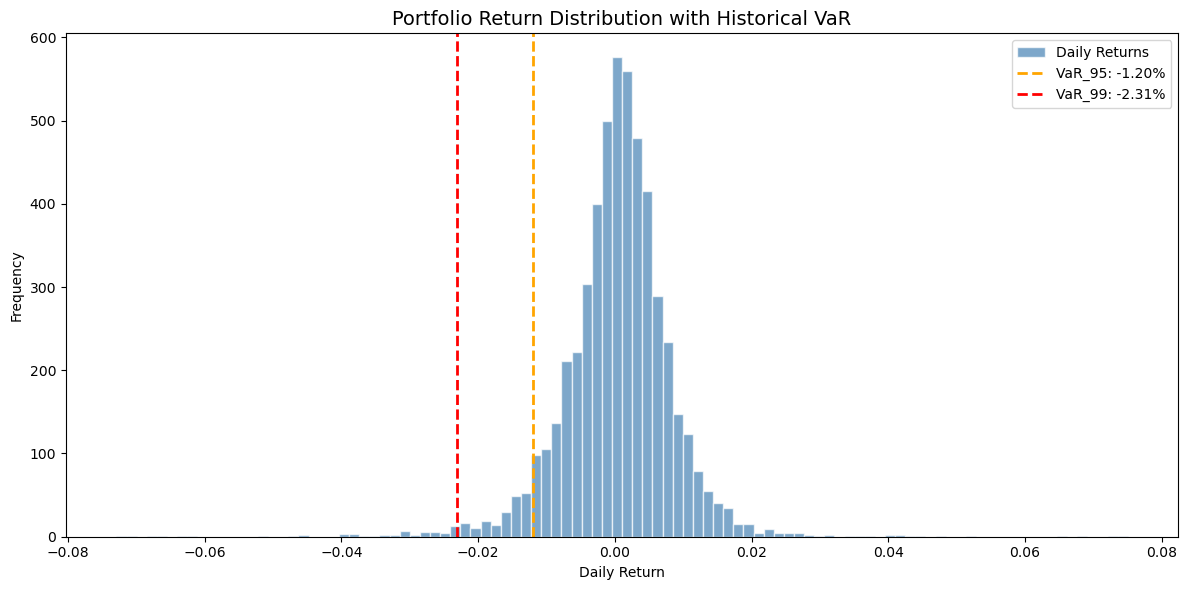

CVaR_95 : -0.0197 (-1.97%)
CVaR_99 : -0.0349 (-3.49%)
========== Risk Metrics Summary ==========
Metric              95%        99%
-----------------------------------
VaR              -1.20%     -2.31%
CVaR             -1.97%     -3.49%
Difference       -0.77%     -1.19%


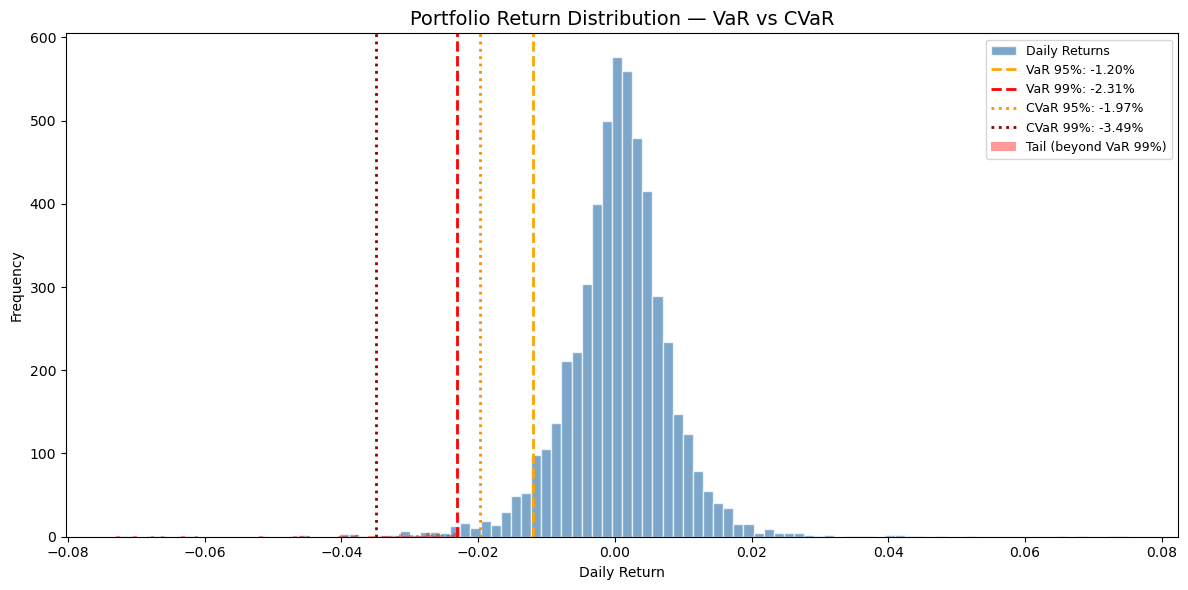

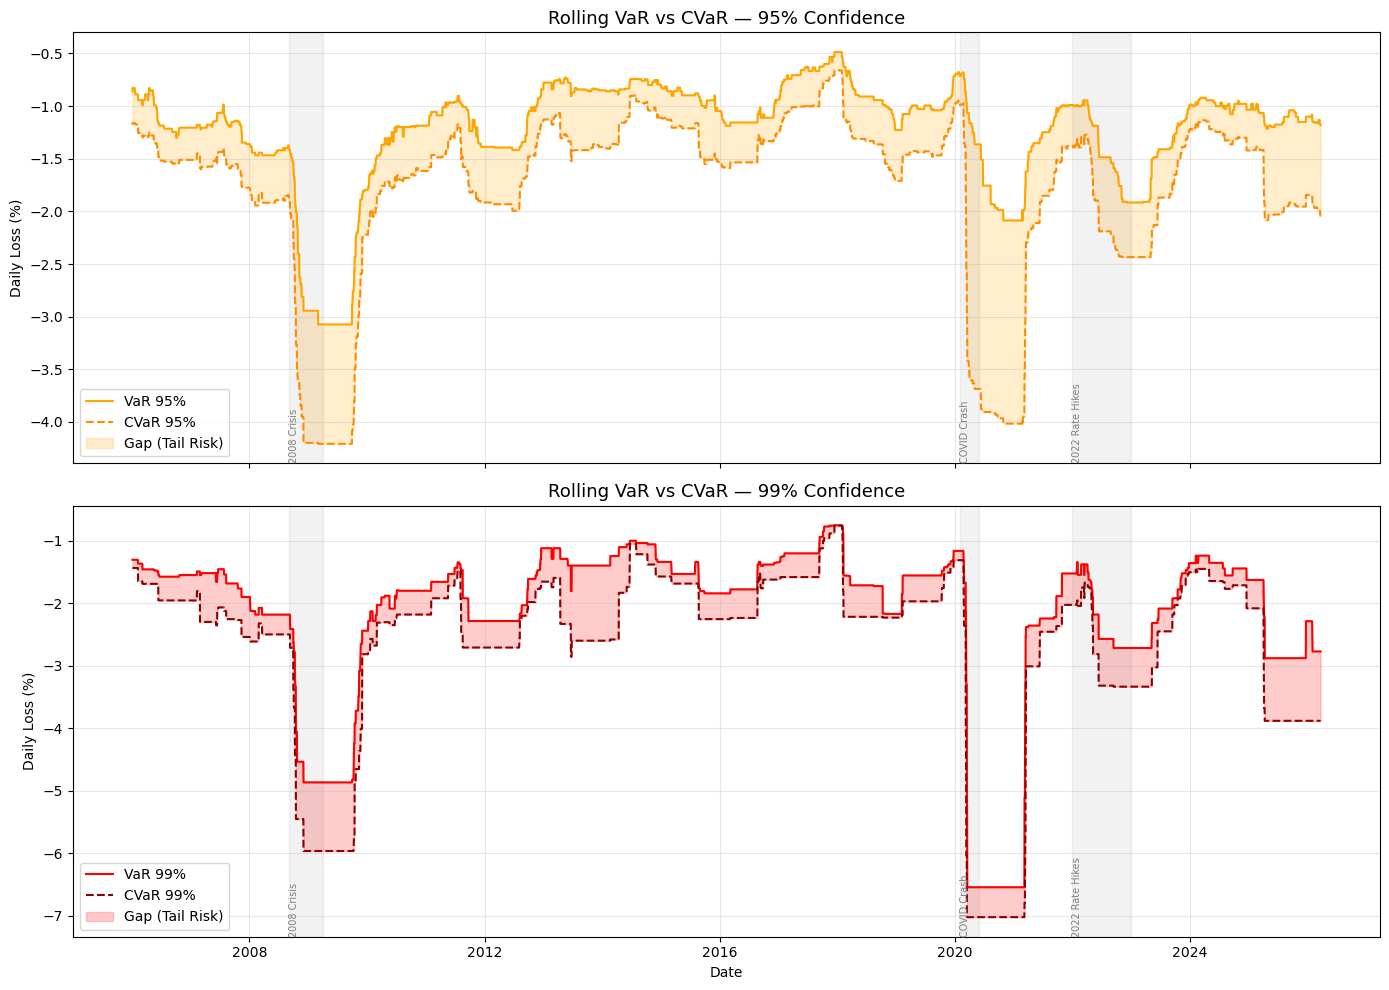

            SPY_Return  QQQ_Return  XLE_Return  GLD_Return  TLT_Return
SPY_Return    1.000000    0.920134    0.722143    0.057179   -0.304199
QQQ_Return    0.920134    1.000000    0.565594    0.044589   -0.252930
XLE_Return    0.722143    0.565594    1.000000    0.159497   -0.309088
GLD_Return    0.057179    0.044589    0.159497    1.000000    0.155142
TLT_Return   -0.304199   -0.252930   -0.309088    0.155142    1.000000


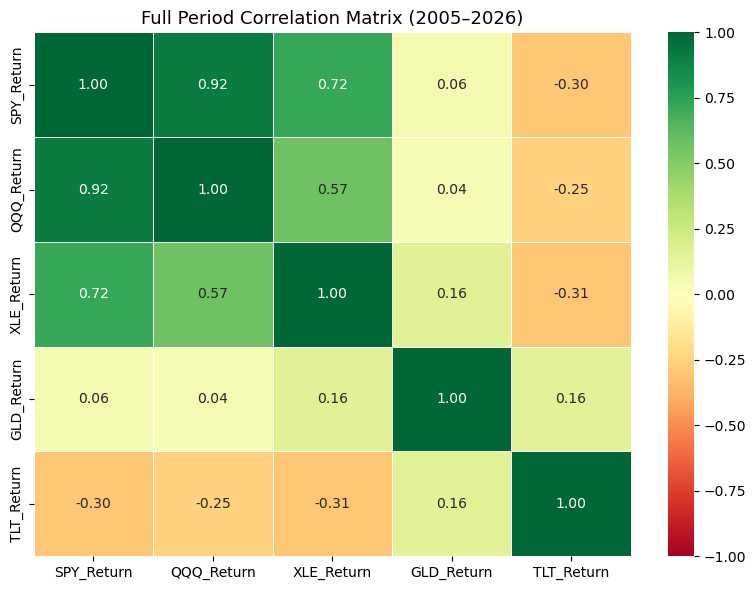

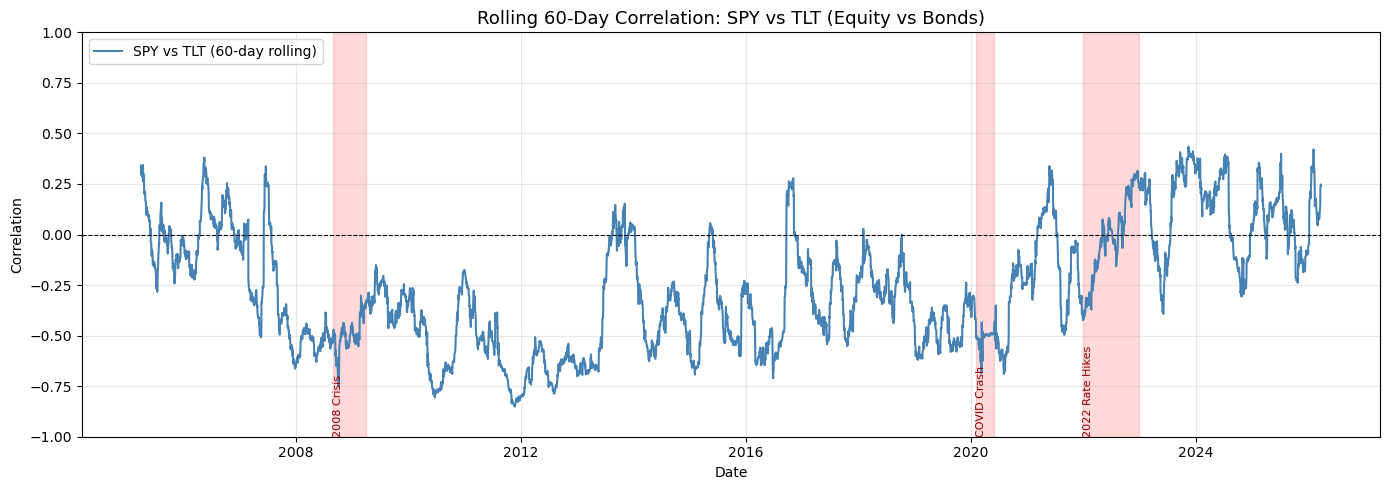

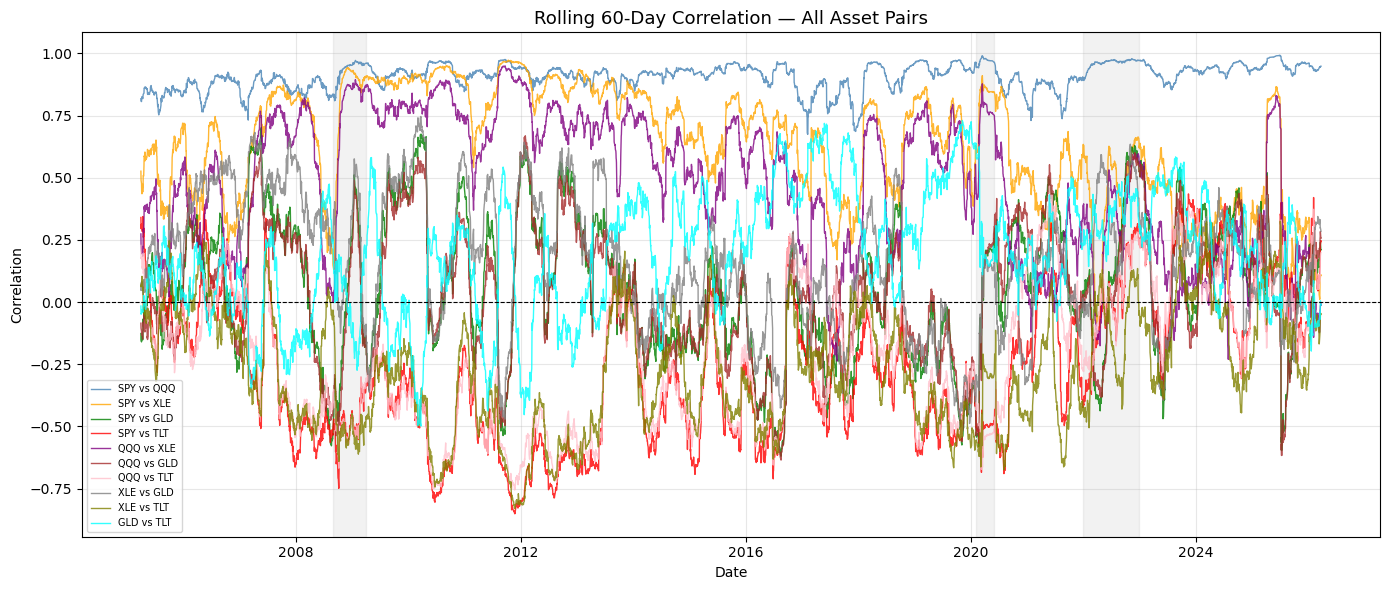

C:\Users\Intel\AppData\Local\Temp\ipykernel_35992\2342473874.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


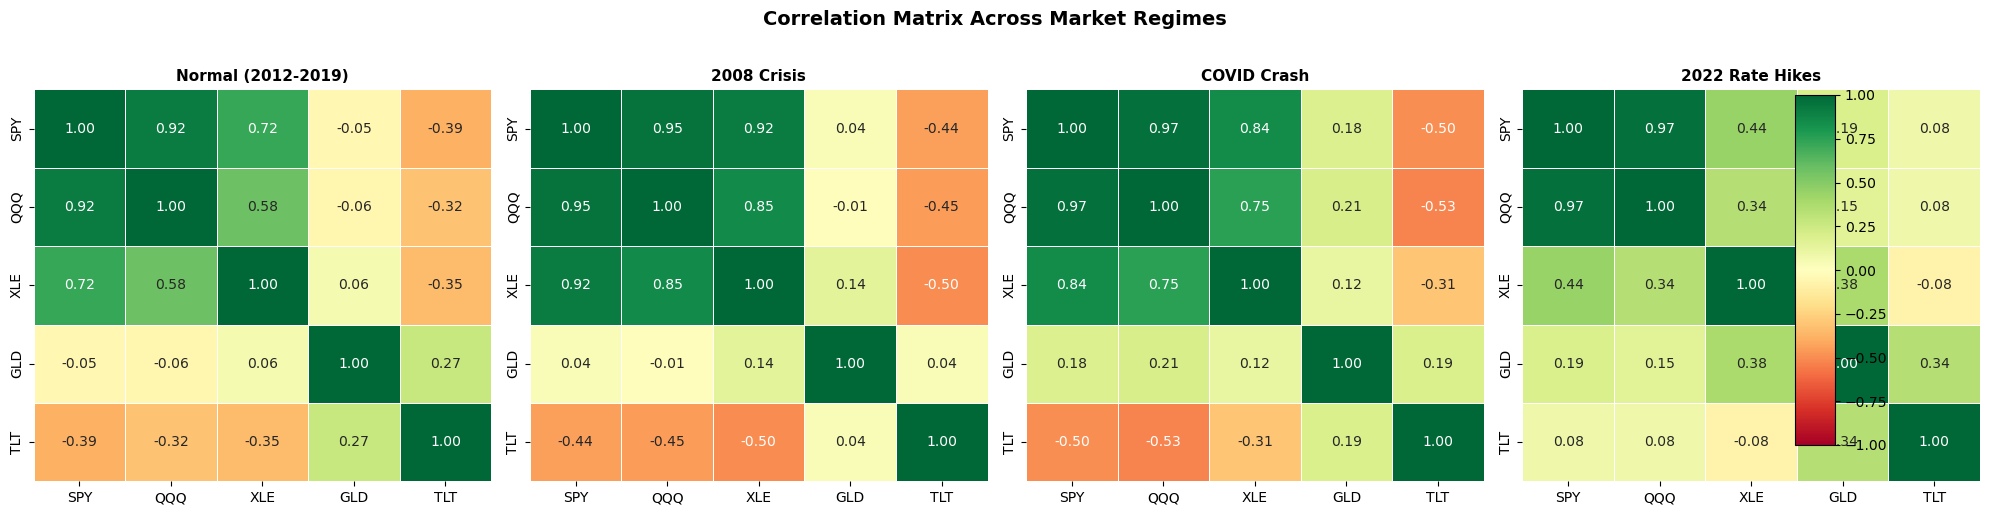

Regime                      Portfolio Vol   Weighted Avg Vol   Div Benefit
---------------------------------------------------------------------------
Normal (2012-2019)                  8.85%             15.13%        41.52%
2008 Crisis                        35.62%             49.85%        28.54%
COVID Crash                        35.81%             50.53%        29.14%
2022 Rate Hikes                    17.37%             25.49%        31.85%


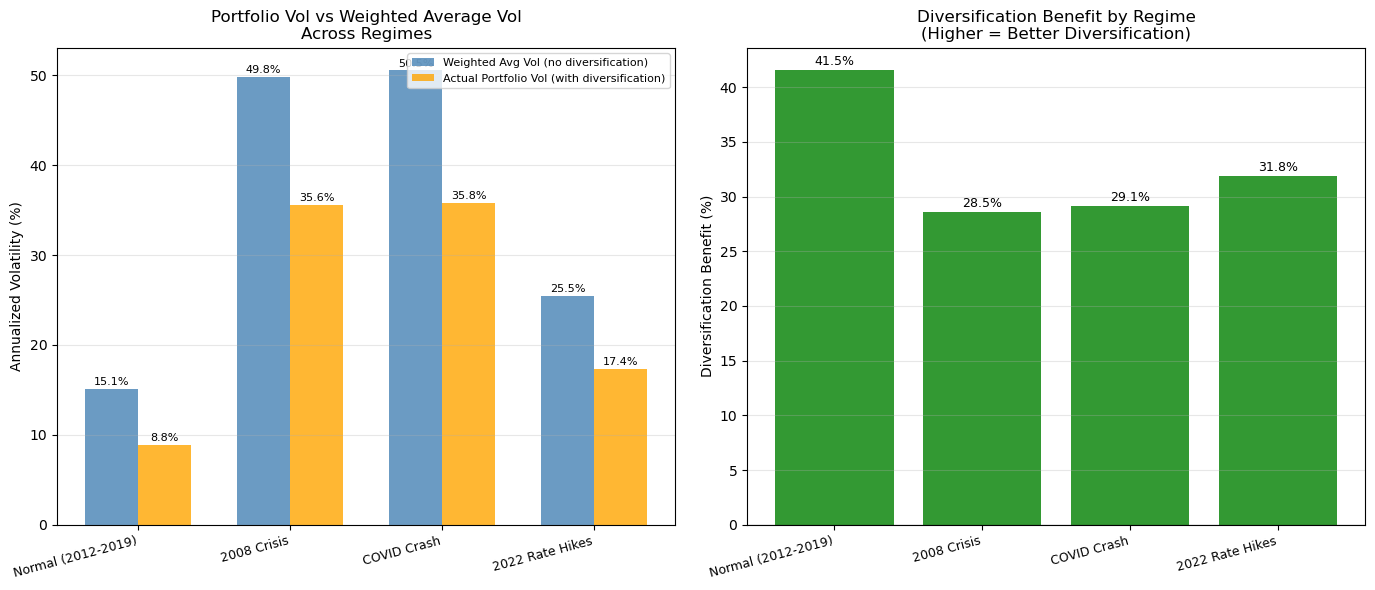

High Correlation Days :  3
Low Correlation Days :  5276


SyntaxError: incomplete input (2252947190.py, line 1)

SyntaxError: incomplete input (2252947190.py, line 1)

In [1]:
%run 02_var_cvar.ipynb
%run 03_correlation_breakdown.ipynb

In [6]:
rolling_avg_corr = pd.DataFrame(rolling_corr).mean(axis = 1)
rolling_avg_corr.index = Portfolio.index[len(Portfolio) - len(rolling_avg_corr):]
threshold = 0.2
high_avg_corr = rolling_avg_corr[rolling_avg_corr >= threshold].index
low_avg_corr = rolling_avg_corr[rolling_avg_corr < threshold].index
print("High Correlation Days : ", len(high_avg_corr))
print("Low Correlation Days : " , len(low_avg_corr))

High Correlation Days :  1946
Low Correlation Days :  3333


In [8]:
weights = np.array([ 0.2 , 0.2 , 0.2 , 0.2 , 0.2])
Portfolio["Portfolio_Return"] = Portfolio[['SPY_Return', 'QQQ_Return', 
                                           'XLE_Return', 'GLD_Return', 
                                           'TLT_Return']].values @ weights

In [10]:
def VaR_cVaR( Returns , cl):
    VaR = np.percentile(Returns , (1 - cl)*100)
    cVaR = Returns[Returns <= VaR].mean()
    return VaR, cVaR 
High_corr_return = Portfolio.loc[Portfolio.index.isin(high_avg_corr), 'Portfolio_Return']
Low_corr_return = Portfolio.loc[Portfolio.index.isin(low_avg_corr) , 'Portfolio_Return']

for cl in [0.95, 0.99]:
    var_high, cvar_high = VaR_cVaR(High_corr_return, cl)
    var_low,  cvar_low  = VaR_cVaR(Low_corr_return,  cl)
    
    print(f"\n--- Confidence Level: {int(cl*100)}% ---")
    print(f"{'Metric':<10} {'Low Corr Regime':>18} {'High Corr Regime':>18}")
    print(f"{'VaR':<10} {var_low*100:>17.2f}% {var_high*100:>17.2f}%")
    print(f"{'CVaR':<10} {cvar_low*100:>17.2f}% {cvar_high*100:>17.2f}%")




--- Confidence Level: 95% ---
Metric        Low Corr Regime   High Corr Regime
VaR                    -1.19%             -1.22%
CVaR                   -2.06%             -1.83%

--- Confidence Level: 99% ---
Metric        Low Corr Regime   High Corr Regime
VaR                    -2.40%             -2.24%
CVaR                   -3.85%             -2.88%


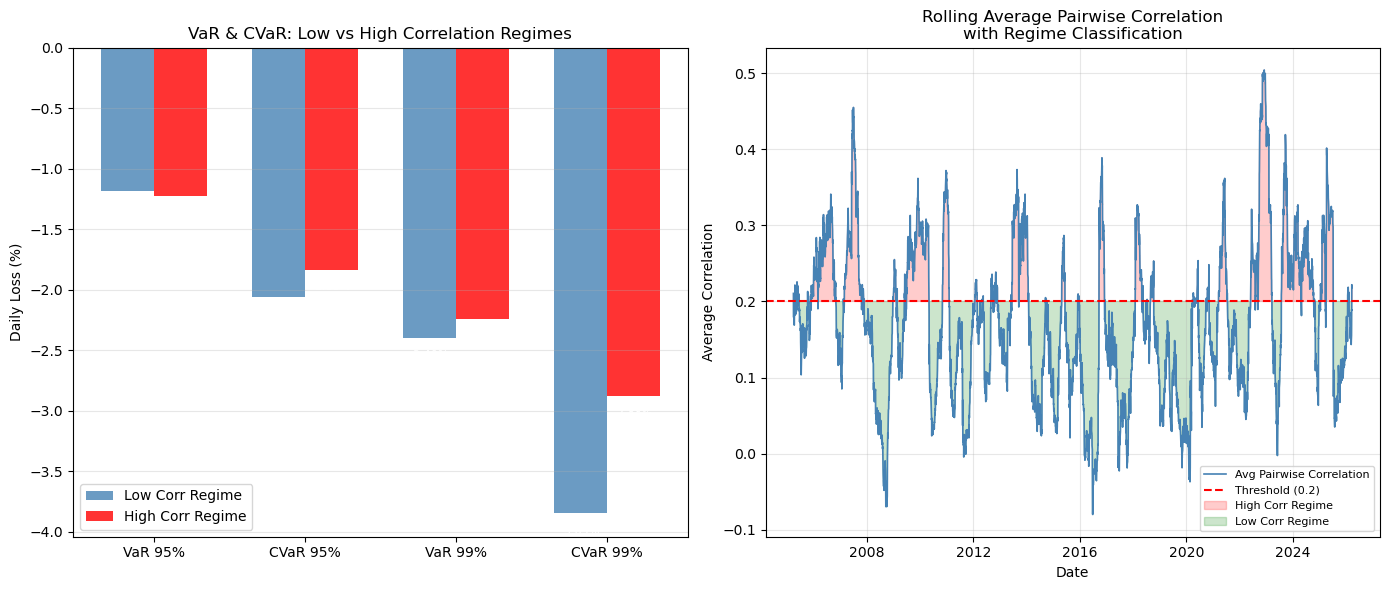

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

var95_low,  cvar95_low  = VaR_cVaR(Low_corr_return,  0.95)
var95_high, cvar95_high = VaR_cVaR(High_corr_return, 0.95)
var99_low,  cvar99_low  = VaR_cVaR(Low_corr_return,  0.99)
var99_high, cvar99_high = VaR_cVaR(High_corr_return, 0.99)

metrics   = ['VaR 95%', 'CVaR 95%', 'VaR 99%', 'CVaR 99%']
low_vals  = [var95_low*100,  cvar95_low*100,  var99_low*100,  cvar99_low*100]
high_vals = [var95_high*100, cvar95_high*100, var99_high*100, cvar99_high*100]

x     = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, low_vals,  width, label='Low Corr Regime',  color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, high_vals, width, label='High Corr Regime', color='red',       alpha=0.8)

axes[0].set_title('VaR & CVaR: Low vs High Correlation Regimes', fontsize=12)
axes[0].set_ylabel('Daily Loss (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.1,
                 f'{bar.get_height():.2f}%', ha='center', va='top', fontsize=8, color='white')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.1,
                 f'{bar.get_height():.2f}%', ha='center', va='top', fontsize=8, color='white')

axes[1].plot(rolling_avg_corr.index, rolling_avg_corr,
             color='steelblue', linewidth=1.2, label='Avg Pairwise Correlation')
axes[1].axhline(threshold, color='red', linewidth=1.5,
                linestyle='--', label=f'Threshold ({threshold})')
axes[1].fill_between(rolling_avg_corr.index, rolling_avg_corr, threshold,
                     where=rolling_avg_corr >= threshold,
                     color='red', alpha=0.2, label='High Corr Regime')
axes[1].fill_between(rolling_avg_corr.index, rolling_avg_corr, threshold,
                     where=rolling_avg_corr < threshold,
                     color='green', alpha=0.2, label='Low Corr Regime')

axes[1].set_title('Rolling Average Pairwise Correlation\nwith Regime Classification', fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Correlation')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('images/combined_stress_analysis.png', dpi=150, bbox_inches='tight')
plt.show()